### Step 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_case_type_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

TUNED_CKPT = CKPT_DIR / "lr5e4_base24_bs2_cont_to_50_best.pt"
MIXED_T010_CKPT = CKPT_DIR / "phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt"
MIXED_T015_CKPT = CKPT_DIR / "ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("TUNED_CKPT exists:", TUNED_CKPT.exists())
print("MIXED_T010_CKPT exists:", MIXED_T010_CKPT.exists())
print("MIXED_T015_CKPT exists:", MIXED_T015_CKPT.exists())

Mounted at /content/drive
device: cuda
VAL_MANIFEST exists: True
TUNED_CKPT exists: True
MIXED_T010_CKPT exists: True
MIXED_T015_CKPT exists: True


### Step 2 — Optional title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Case-Type Analysis
## Models
- tuned baseline
- mixed T=0.10, alpha=0.30, max_weight=3.0
- mixed T=0.15, alpha=0.30, max_weight=3.0
"""))


# CT-to-Dose Phase 4: Case-Type Analysis
## Models
- tuned baseline
- mixed T=0.10, alpha=0.30, max_weight=3.0
- mixed T=0.15, alpha=0.30, max_weight=3.0


### Step 3 — Dataset + model definitions

In [3]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

def denormalize_ct(x_norm):
    return x_norm * (1500.0 + 1024.0) - 1024.0

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)
        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Step 4 — Prediction helpers

In [4]:
@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    x0, x1 = dataset[idx]
    x0_t = x0.unsqueeze(0).to(device)
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()
    return ct_vol, gt_vol, pred


def find_best_dose_slice_index(volume):
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))


def find_peak_xy(volume, slice_idx):
    slice_2d = volume[slice_idx]
    return np.unravel_index(np.argmax(slice_2d), slice_2d.shape)

### Step 5 — Unified evaluation config + metrics

In [5]:
EVAL_THRESHOLD = 0.10
EVAL_THRESHOLD_MODE = "absolute"

print("Unified evaluation threshold:", EVAL_THRESHOLD)

def get_case_threshold(gt_vol, threshold=0.10, mode="absolute"):
    if mode == "absolute":
        T = float(threshold)
    elif mode == "relative_to_case_max":
        T = float(threshold) * float(gt_vol.max())
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return max(T, 1e-8)


def compute_targeted_eval_metrics(gt_vol, pred_vol, threshold=0.10, mode="absolute"):
    T = get_case_threshold(gt_vol, threshold=threshold, mode=mode)

    abs_err = np.abs(pred_vol - gt_vol)
    sq_err = (pred_vol - gt_vol) ** 2

    weight = np.maximum(T, gt_vol) / T
    weighted_mse = float(np.mean(weight * sq_err))

    high_mask = gt_vol >= T
    outside_mask = gt_vol < T

    gt_max = float(gt_vol.max())
    peak_core_mask = gt_vol >= (0.8 * gt_max)
    peak_shoulder_mask = (gt_vol >= 0.3 * gt_max) & (gt_vol < 0.8 * gt_max)

    def safe_mean(arr):
        return float(np.mean(arr)) if arr.size > 0 else np.nan

    def safe_max(arr):
        return float(np.max(arr)) if arr.size > 0 else np.nan

    def safe_p95(arr):
        return float(np.percentile(arr, 95)) if arr.size > 0 else np.nan

    def safe_rel_err(gt_arr, pred_arr):
        denom = np.sum(np.abs(gt_arr))
        if gt_arr.size == 0 or denom <= 1e-8:
            return np.nan
        return float(100.0 * np.sum(np.abs(pred_arr - gt_arr)) / denom)

    return {
        "overall_mse": float(np.mean(sq_err)),
        "overall_mae": float(np.mean(abs_err)),
        "weighted_mse": weighted_mse,

        "high_mse": safe_mean(sq_err[high_mask]),
        "high_mae": safe_mean(abs_err[high_mask]),
        "high_rel_err_pct": safe_rel_err(gt_vol[high_mask], pred_vol[high_mask]),

        "outside_mse": safe_mean(sq_err[outside_mask]),
        "outside_mae": safe_mean(abs_err[outside_mask]),
        "outside_max_abs_error": safe_max(abs_err[outside_mask]),
        "outside_p95_abs_error": safe_p95(abs_err[outside_mask]),

        "peak_core_mae": safe_mean(abs_err[peak_core_mask]),
        "peak_shoulder_mae": safe_mean(abs_err[peak_shoulder_mask]),

        "threshold_used": T,
        "num_high_voxels": int(high_mask.sum()),
        "num_outside_voxels": int(outside_mask.sum()),
    }

Unified evaluation threshold: 0.1


### Step 6 — Bone-in-beam heuristic + extra case features

In [6]:
def compute_bone_in_beam_heuristic(
    ct_vol_norm,
    gt_vol,
    threshold=0.10,
    band_halfwidth=1,
    bone_hu_threshold=300.0,
    min_bone_fraction=0.05
):
    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    gt_slice = gt_vol[slice_idx]
    ct_slice_hu = denormalize_ct(ct_vol_norm[slice_idx])

    y0 = max(0, peak_y - band_halfwidth)
    y1 = min(gt_slice.shape[0], peak_y + band_halfwidth + 1)

    dose_band = gt_slice[y0:y1, :]
    ct_band_hu = ct_slice_hu[y0:y1, :]

    relevant_mask = dose_band >= threshold

    if relevant_mask.sum() == 0:
        return {
            "bone_in_beam_candidate": False,
            "bone_fraction_in_relevant_band": 0.0,
            "max_hu_in_relevant_band": float(np.max(ct_band_hu)),
            "beam_slice_idx": int(slice_idx),
            "beam_peak_y": int(peak_y),
            "beam_peak_x": int(peak_x),
        }

    bone_mask = (ct_band_hu >= bone_hu_threshold) & relevant_mask
    bone_fraction = float(bone_mask.sum() / relevant_mask.sum())
    max_hu = float(np.max(ct_band_hu[relevant_mask]))

    return {
        "bone_in_beam_candidate": bone_fraction >= min_bone_fraction,
        "bone_fraction_in_relevant_band": bone_fraction,
        "max_hu_in_relevant_band": max_hu,
        "beam_slice_idx": int(slice_idx),
        "beam_peak_y": int(peak_y),
        "beam_peak_x": int(peak_x),
    }


def compute_case_structure_features(ct_vol_norm, gt_vol, threshold=0.10):
    slice_idx = find_best_dose_slice_index(gt_vol)
    gt_slice = gt_vol[slice_idx]
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    gt_along = gt_slice[peak_y, :]
    gt_perp = gt_slice[:, peak_x]

    gt_max = float(gt_vol.max())
    relevant_mask = gt_slice >= threshold

    ct_slice_hu = denormalize_ct(ct_vol_norm[slice_idx])

    return {
        "gt_max": gt_max,
        "dose_sum_slice": float(np.sum(gt_slice)),
        "along_peak_value": float(np.max(gt_along)),
        "perp_peak_value": float(np.max(gt_perp)),
        "relevant_fraction_in_slice": float(np.mean(relevant_mask)),
        "ct_hu_mean_relevant": float(np.mean(ct_slice_hu[relevant_mask])) if relevant_mask.sum() > 0 else np.nan,
        "ct_hu_std_relevant": float(np.std(ct_slice_hu[relevant_mask])) if relevant_mask.sum() > 0 else np.nan,
    }

### Step 7 — Load dataset and all models

In [7]:
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

model_specs = {
    "tuned": TUNED_CKPT,
    "mixed_T010_a030_mw3": MIXED_T010_CKPT,
    "mixed_T015_a030_mw3": MIXED_T015_CKPT,
}

models = {}

for model_name, ckpt_path in model_specs.items():
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    models[model_name] = model
    print("Loaded:", model_name, "from", ckpt_path)

print("Validation samples:", len(val_dataset_3d))

Loaded: tuned from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/lr5e4_base24_bs2_cont_to_50_best.pt
Loaded: mixed_T010_a030_mw3 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt
Loaded: mixed_T015_a030_mw3 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt
Validation samples: 500


### Step 8 — Build full case-model table

In [8]:
all_rows = []

for idx in range(len(val_dataset_3d)):
    ct_vol, gt_vol, _ = get_flow_prediction(models["tuned"], val_dataset_3d, idx, device, n_steps=30)

    bone_info = compute_bone_in_beam_heuristic(
        ct_vol_norm=ct_vol,
        gt_vol=gt_vol,
        threshold=EVAL_THRESHOLD,
        band_halfwidth=1,
        bone_hu_threshold=300.0,
        min_bone_fraction=0.05
    )

    structure_info = compute_case_structure_features(
        ct_vol_norm=ct_vol,
        gt_vol=gt_vol,
        threshold=EVAL_THRESHOLD
    )

    for model_name, model in models.items():
        _, _, pred_vol = get_flow_prediction(model, val_dataset_3d, idx, device, n_steps=30)

        metrics = compute_targeted_eval_metrics(
            gt_vol,
            pred_vol,
            threshold=EVAL_THRESHOLD,
            mode=EVAL_THRESHOLD_MODE
        )

        all_rows.append({
            "sample_idx": idx,
            "model": model_name,
            **bone_info,
            **structure_info,
            **metrics
        })

comparison_df = pd.DataFrame(all_rows)

comparison_csv = OUT_DIR / "ct2dose_case_type_analysis_casewise_metrics.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("Saved:", comparison_csv)
display(comparison_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_casewise_metrics.csv


,sample_idx,model,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,...,high_rel_err_pct,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae,threshold_used,num_high_voxels,num_outside_voxels
0,0,tuned,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,2.674173,0.000009,0.002039,0.033033,0.005827,0.116184,0.040654,0.1,4792,27976
1,0,mixed_T010_a030_mw3,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,3.067758,0.000010,0.002213,0.030378,0.006510,0.016533,0.026898,0.1,4792,27976
2,0,mixed_T015_a030_mw3,True,0.184211,830.923096,16,16,0,3.831937,93.760818,...,4.279956,0.000010,0.002287,0.029699,0.006290,0.134365,0.034779,0.1,4792,27976
3,1,tuned,False,0.000000,48.529053,16,16,0,3.443971,89.784882,...,2.663383,0.000019,0.002665,0.048242,0.009109,0.119688,0.050971,0.1,4218,28550
4,1,mixed_T010_a030_mw3,False,0.000000,48.529053,16,16,0,3.443971,89.784882,...,2.468965,0.000024,0.003019,0.050761,0.010374,0.032907,0.030689,0.1,4218,28550


### Step 9 — Build per-case winner table

In [9]:
case_info_df = comparison_df[comparison_df["model"] == "tuned"][
    [
        "sample_idx",
        "bone_in_beam_candidate",
        "bone_fraction_in_relevant_band",
        "max_hu_in_relevant_band",
        "beam_slice_idx",
        "beam_peak_y",
        "beam_peak_x",
        "gt_max",
        "dose_sum_slice",
        "relevant_fraction_in_slice",
        "ct_hu_mean_relevant",
        "ct_hu_std_relevant",
    ]
].copy().reset_index(drop=True)

metric_cols = [
    "overall_mae",
    "weighted_mse",
    "high_mae",
    "outside_mae",
    "outside_max_abs_error",
    "peak_core_mae",
    "peak_shoulder_mae",
]

def compute_winner_and_margin(df, metric_name):
    pivot = df.pivot(index="sample_idx", columns="model", values=metric_name).copy()

    winner = pivot.idxmin(axis=1)

    sorted_vals = np.sort(pivot.values, axis=1)
    margin = sorted_vals[:, 1] - sorted_vals[:, 0]

    out = pd.DataFrame({
        "sample_idx": pivot.index,
        f"{metric_name}_winner": winner.values,
        f"{metric_name}_winner_margin": margin
    })
    return out

winner_tables = [case_info_df]

for metric in metric_cols:
    winner_tables.append(compute_winner_and_margin(comparison_df, metric))

case_winner_df = winner_tables[0]
for t in winner_tables[1:]:
    case_winner_df = case_winner_df.merge(t, on="sample_idx", how="left")

case_winner_csv = OUT_DIR / "ct2dose_case_type_analysis_winner_table.csv"
case_winner_df.to_csv(case_winner_csv, index=False)

print("Saved:", case_winner_csv)
display(case_winner_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_winner_table.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,relevant_fraction_in_slice,...,high_mae_winner,high_mae_winner_margin,outside_mae_winner,outside_mae_winner_margin,outside_max_abs_error_winner,outside_max_abs_error_winner_margin,peak_core_mae_winner,peak_core_mae_winner_margin,peak_shoulder_mae_winner,peak_shoulder_mae_winner_margin
0,0,True,0.184211,830.923096,16,16,0,3.831937,93.760818,0.234375,...,tuned,0.000737,tuned,0.000173,mixed_T015_a030_mw3,0.000680,mixed_T010_a030_mw3,0.099651,mixed_T010_a030_mw3,0.007882
1,1,False,0.000000,48.529053,16,16,0,3.443971,89.784882,0.209961,...,mixed_T015_a030_mw3,0.000162,tuned,0.000152,tuned,0.002518,mixed_T010_a030_mw3,0.042234,mixed_T015_a030_mw3,0.003790
2,2,True,0.117647,903.819946,16,16,0,2.209354,70.654045,0.176758,...,mixed_T010_a030_mw3,0.000444,tuned,0.000013,mixed_T010_a030_mw3,0.001858,mixed_T015_a030_mw3,0.003015,tuned,0.001756
3,3,True,0.435897,746.846069,16,16,0,3.839338,84.674194,0.200195,...,tuned,0.000494,mixed_T010_a030_mw3,0.000064,mixed_T015_a030_mw3,0.003248,mixed_T015_a030_mw3,0.015145,mixed_T015_a030_mw3,0.010895
4,4,False,0.000000,90.889771,16,16,0,2.477244,90.857071,0.227539,...,mixed_T015_a030_mw3,0.000310,mixed_T015_a030_mw3,0.000205,mixed_T010_a030_mw3,0.001002,mixed_T015_a030_mw3,0.015841,mixed_T015_a030_mw3,0.002042


### Step 10 — Overall winner counts

In [10]:
winner_count_rows = []

for metric in metric_cols:
    vc = case_winner_df[f"{metric}_winner"].value_counts()
    for model_name, count in vc.items():
        winner_count_rows.append({
            "metric": metric,
            "winner_model": model_name,
            "num_cases_won": int(count)
        })

winner_count_df = pd.DataFrame(winner_count_rows)

winner_count_csv = OUT_DIR / "ct2dose_case_type_analysis_winner_counts.csv"
winner_count_df.to_csv(winner_count_csv, index=False)

print("Saved:", winner_count_csv)
display(winner_count_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_winner_counts.csv


,metric,winner_model,num_cases_won
0,overall_mae,tuned,225
1,overall_mae,mixed_T015_a030_mw3,144
2,overall_mae,mixed_T010_a030_mw3,131
3,weighted_mse,mixed_T015_a030_mw3,170
4,weighted_mse,mixed_T010_a030_mw3,165
5,weighted_mse,tuned,165
6,high_mae,mixed_T010_a030_mw3,207
7,high_mae,tuned,148
8,high_mae,mixed_T015_a030_mw3,145
9,outside_mae,tuned,253


### Step 11 — Winner counts by bone/non-bone subset

In [11]:
subset_rows = []

for subset_value, subset_tag in [(True, "bone_in_beam_candidate"), (False, "non_bone_candidate")]:
    sub = case_winner_df[case_winner_df["bone_in_beam_candidate"] == subset_value].copy()

    for metric in metric_cols:
        vc = sub[f"{metric}_winner"].value_counts()
        for model_name, count in vc.items():
            subset_rows.append({
                "subset": subset_tag,
                "metric": metric,
                "winner_model": model_name,
                "num_cases_won": int(count)
            })

subset_winner_df = pd.DataFrame(subset_rows)

subset_winner_csv = OUT_DIR / "ct2dose_case_type_analysis_subset_winner_counts.csv"
subset_winner_df.to_csv(subset_winner_csv, index=False)

print("Saved:", subset_winner_csv)
display(subset_winner_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_subset_winner_counts.csv


,subset,metric,winner_model,num_cases_won
0,bone_in_beam_candidate,overall_mae,tuned,73
1,bone_in_beam_candidate,overall_mae,mixed_T010_a030_mw3,41
2,bone_in_beam_candidate,overall_mae,mixed_T015_a030_mw3,30
3,bone_in_beam_candidate,weighted_mse,mixed_T010_a030_mw3,56
4,bone_in_beam_candidate,weighted_mse,tuned,46
5,bone_in_beam_candidate,weighted_mse,mixed_T015_a030_mw3,42
6,bone_in_beam_candidate,high_mae,mixed_T010_a030_mw3,64
7,bone_in_beam_candidate,high_mae,tuned,48
8,bone_in_beam_candidate,high_mae,mixed_T015_a030_mw3,32
9,bone_in_beam_candidate,outside_mae,tuned,82


### Step 12 — Wide comparison table for deltas

In [12]:
wide_weighted = comparison_df.pivot(index="sample_idx", columns="model", values="weighted_mse").reset_index()
wide_overall = comparison_df.pivot(index="sample_idx", columns="model", values="overall_mae").reset_index()
wide_high = comparison_df.pivot(index="sample_idx", columns="model", values="high_mae").reset_index()

wide_weighted = wide_weighted.rename(columns={
    "tuned": "weighted_tuned",
    "mixed_T010_a030_mw3": "weighted_t010",
    "mixed_T015_a030_mw3": "weighted_t015",
})

wide_overall = wide_overall.rename(columns={
    "tuned": "overall_tuned",
    "mixed_T010_a030_mw3": "overall_t010",
    "mixed_T015_a030_mw3": "overall_t015",
})

wide_high = wide_high.rename(columns={
    "tuned": "high_tuned",
    "mixed_T010_a030_mw3": "high_t010",
    "mixed_T015_a030_mw3": "high_t015",
})

case_compare_df = case_info_df.merge(wide_weighted, on="sample_idx", how="left")
case_compare_df = case_compare_df.merge(wide_overall, on="sample_idx", how="left")
case_compare_df = case_compare_df.merge(wide_high, on="sample_idx", how="left")

case_compare_df["delta_weighted_t010_vs_tuned"] = case_compare_df["weighted_t010"] - case_compare_df["weighted_tuned"]
case_compare_df["delta_weighted_t015_vs_tuned"] = case_compare_df["weighted_t015"] - case_compare_df["weighted_tuned"]

case_compare_df["delta_overall_t010_vs_tuned"] = case_compare_df["overall_t010"] - case_compare_df["overall_tuned"]
case_compare_df["delta_overall_t015_vs_tuned"] = case_compare_df["overall_t015"] - case_compare_df["overall_tuned"]

case_compare_df["delta_high_t010_vs_tuned"] = case_compare_df["high_t010"] - case_compare_df["high_tuned"]
case_compare_df["delta_high_t015_vs_tuned"] = case_compare_df["high_t015"] - case_compare_df["high_tuned"]

case_compare_csv = OUT_DIR / "ct2dose_case_type_analysis_case_compare.csv"
case_compare_df.to_csv(case_compare_csv, index=False)

print("Saved:", case_compare_csv)
display(case_compare_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_case_compare.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,relevant_fraction_in_slice,...,overall_tuned,high_t010,high_t015,high_tuned,delta_weighted_t010_vs_tuned,delta_weighted_t015_vs_tuned,delta_overall_t010_vs_tuned,delta_overall_t015_vs_tuned,delta_high_t010_vs_tuned,delta_high_t015_vs_tuned
0,0,True,0.184211,830.923096,16,16,0,3.831937,93.760818,0.234375,...,0.002473,0.005744,0.008013,0.005007,-0.000021,0.000018,0.000256,0.000651,0.000737,0.003006
1,1,False,0.000000,48.529053,16,16,0,3.443971,89.784882,0.209961,...,0.002947,0.004500,0.004338,0.004855,-0.000033,-0.000041,0.000263,0.000066,-0.000354,-0.000517
2,2,True,0.117647,903.819946,16,16,0,2.209354,70.654045,0.176758,...,0.003152,0.003901,0.004991,0.004345,0.000004,0.000002,0.000152,0.000068,-0.000444,0.000646
3,3,True,0.435897,746.846069,16,16,0,3.839338,84.674194,0.200195,...,0.003207,0.008657,0.011287,0.008163,0.000056,0.000010,0.000023,0.000558,0.000494,0.003124
4,4,False,0.000000,90.889771,16,16,0,2.477244,90.857071,0.227539,...,0.002631,0.005940,0.004073,0.004382,0.000012,-0.000005,0.000193,-0.000217,0.001557,-0.000310


### Step 13 — Hard-case candidate tables

In [13]:
hard_cases_by_tuned = case_compare_df.sort_values("weighted_tuned", ascending=False).reset_index(drop=True)
hard_cases_csv = OUT_DIR / "ct2dose_case_type_analysis_hard_cases_by_tuned.csv"
hard_cases_by_tuned.to_csv(hard_cases_csv, index=False)

print("Saved:", hard_cases_csv)
display(hard_cases_by_tuned.head(20))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_hard_cases_by_tuned.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,relevant_fraction_in_slice,...,overall_tuned,high_t010,high_t015,high_tuned,delta_weighted_t010_vs_tuned,delta_weighted_t015_vs_tuned,delta_overall_t010_vs_tuned,delta_overall_t015_vs_tuned,delta_high_t010_vs_tuned,delta_high_t015_vs_tuned
0,221,True,0.230769,1448.149902,16,16,0,3.737234,92.782806,0.227539,...,0.003337,0.011144,0.014101,0.010044,-0.000320,-0.000348,0.000241,0.000838,0.001100,0.004057
1,50,True,0.617647,1500.000000,16,16,0,3.545587,83.796783,0.199219,...,0.005658,0.016237,0.018117,0.014967,0.000073,0.000004,0.000433,0.001121,0.001270,0.003150
2,330,True,0.227273,722.076172,16,16,0,3.588140,94.505432,0.230469,...,0.003635,0.010030,0.012250,0.008851,-0.000139,-0.000034,0.000258,0.000604,0.001179,0.003399
3,263,True,0.065217,711.566284,16,16,0,3.037314,89.884720,0.215820,...,0.003787,0.006479,0.006403,0.008027,-0.000158,-0.000148,-0.000220,-0.000386,-0.001547,-0.001624
4,10,True,0.137255,798.227905,16,16,0,3.374628,96.193756,0.223633,...,0.004320,0.009382,0.012331,0.010593,-0.000049,0.000042,-0.000074,0.000375,-0.001210,0.001739
5,201,False,0.000000,45.768188,16,16,0,3.330770,94.934036,0.205078,...,0.003445,0.005751,0.005734,0.007774,-0.000125,-0.000110,-0.000387,-0.000364,-0.002023,-0.002040
6,96,False,0.000000,165.579712,16,16,0,3.090489,97.025513,0.235352,...,0.004442,0.011084,0.008543,0.010028,0.000073,-0.000083,0.000236,-0.000086,0.001057,-0.001485
7,179,False,0.000000,-458.524536,21,16,0,2.066106,98.533966,0.396484,...,0.004550,0.006605,0.006885,0.011661,-0.000114,-0.000124,-0.000688,-0.000733,-0.005056,-0.004776
8,222,False,0.000000,43.064819,16,16,0,3.525735,91.377075,0.212891,...,0.003229,0.004490,0.003654,0.007223,-0.000094,-0.000126,-0.000212,-0.000403,-0.002733,-0.003569
9,349,True,0.230769,1500.000000,16,16,0,2.673521,88.314911,0.263672,...,0.004322,0.009810,0.009304,0.009770,0.000001,-0.000052,0.000202,0.000068,0.000041,-0.000466


### Step 14 — Cases where T0.10 helps most

In [14]:
t010_help_df = case_compare_df.sort_values("delta_weighted_t010_vs_tuned", ascending=True).reset_index(drop=True)
t015_help_df = case_compare_df.sort_values("delta_weighted_t015_vs_tuned", ascending=True).reset_index(drop=True)

t010_help_csv = OUT_DIR / "ct2dose_case_type_analysis_t010_best_help_cases.csv"
t015_help_csv = OUT_DIR / "ct2dose_case_type_analysis_t015_best_help_cases.csv"

t010_help_df.to_csv(t010_help_csv, index=False)
t015_help_df.to_csv(t015_help_csv, index=False)

print("Saved:", t010_help_csv)
print("Saved:", t015_help_csv)

print("Top 20 cases where T0.10 improves weighted_mse most vs tuned:")
display(t010_help_df.head(20))

print("Top 20 cases where T0.15 improves weighted_mse most vs tuned:")
display(t015_help_df.head(20))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_t010_best_help_cases.csv
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_t015_best_help_cases.csv
Top 20 cases where T0.10 improves weighted_mse most vs tuned:


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,relevant_fraction_in_slice,...,overall_tuned,high_t010,high_t015,high_tuned,delta_weighted_t010_vs_tuned,delta_weighted_t015_vs_tuned,delta_overall_t010_vs_tuned,delta_overall_t015_vs_tuned,delta_high_t010_vs_tuned,delta_high_t015_vs_tuned
0,221,True,0.230769,1448.149902,16,16,0,3.737234,92.782806,0.227539,...,0.003337,0.011144,0.014101,0.010044,-0.000320,-0.000348,0.000241,0.000838,0.001100,0.004057
1,263,True,0.065217,711.566284,16,16,0,3.037314,89.884720,0.215820,...,0.003787,0.006479,0.006403,0.008027,-0.000158,-0.000148,-0.000220,-0.000386,-0.001547,-0.001624
2,330,True,0.227273,722.076172,16,16,0,3.588140,94.505432,0.230469,...,0.003635,0.010030,0.012250,0.008851,-0.000139,-0.000034,0.000258,0.000604,0.001179,0.003399
3,201,False,0.000000,45.768188,16,16,0,3.330770,94.934036,0.205078,...,0.003445,0.005751,0.005734,0.007774,-0.000125,-0.000110,-0.000387,-0.000364,-0.002023,-0.002040
4,179,False,0.000000,-458.524536,21,16,0,2.066106,98.533966,0.396484,...,0.004550,0.006605,0.006885,0.011661,-0.000114,-0.000124,-0.000688,-0.000733,-0.005056,-0.004776
5,469,False,0.000000,46.223633,16,16,0,2.804342,103.509827,0.227539,...,0.003080,0.005020,0.005684,0.006507,-0.000103,-0.000078,-0.000084,-0.000166,-0.001487,-0.000822
6,222,False,0.000000,43.064819,16,16,0,3.525735,91.377075,0.212891,...,0.003229,0.004490,0.003654,0.007223,-0.000094,-0.000126,-0.000212,-0.000403,-0.002733,-0.003569
7,137,False,0.000000,223.307983,16,16,0,3.013430,84.616592,0.199219,...,0.003113,0.005646,0.004968,0.006340,-0.000091,-0.000095,0.000192,-0.000032,-0.000694,-0.001372
8,278,True,0.333333,1118.555664,16,16,0,3.980023,97.533920,0.224609,...,0.003266,0.006125,0.009087,0.008589,-0.000077,-0.000048,-0.000254,0.000155,-0.002464,0.000498
9,191,True,0.150000,684.878662,16,16,0,3.838893,98.520302,0.241211,...,0.002385,0.004195,0.008132,0.007051,-0.000067,-0.000010,-0.000297,0.000365,-0.002856,0.001081


Top 20 cases where T0.15 improves weighted_mse most vs tuned:


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,relevant_fraction_in_slice,...,overall_tuned,high_t010,high_t015,high_tuned,delta_weighted_t010_vs_tuned,delta_weighted_t015_vs_tuned,delta_overall_t010_vs_tuned,delta_overall_t015_vs_tuned,delta_high_t010_vs_tuned,delta_high_t015_vs_tuned
0,221,True,0.230769,1448.149902,16,16,0,3.737234,92.782806,0.227539,...,0.003337,0.011144,0.014101,0.010044,-0.000320,-0.000348,0.000241,0.000838,0.001100,0.004057
1,263,True,0.065217,711.566284,16,16,0,3.037314,89.884720,0.215820,...,0.003787,0.006479,0.006403,0.008027,-0.000158,-0.000148,-0.000220,-0.000386,-0.001547,-0.001624
2,222,False,0.000000,43.064819,16,16,0,3.525735,91.377075,0.212891,...,0.003229,0.004490,0.003654,0.007223,-0.000094,-0.000126,-0.000212,-0.000403,-0.002733,-0.003569
3,179,False,0.000000,-458.524536,21,16,0,2.066106,98.533966,0.396484,...,0.004550,0.006605,0.006885,0.011661,-0.000114,-0.000124,-0.000688,-0.000733,-0.005056,-0.004776
4,201,False,0.000000,45.768188,16,16,0,3.330770,94.934036,0.205078,...,0.003445,0.005751,0.005734,0.007774,-0.000125,-0.000110,-0.000387,-0.000364,-0.002023,-0.002040
5,137,False,0.000000,223.307983,16,16,0,3.013430,84.616592,0.199219,...,0.003113,0.005646,0.004968,0.006340,-0.000091,-0.000095,0.000192,-0.000032,-0.000694,-0.001372
6,270,False,0.000000,39.951660,16,16,0,3.520051,91.839836,0.215820,...,0.003151,0.006033,0.003608,0.006445,-0.000038,-0.000093,0.000038,-0.000481,-0.000412,-0.002837
7,96,False,0.000000,165.579712,16,16,0,3.090489,97.025513,0.235352,...,0.004442,0.011084,0.008543,0.010028,0.000073,-0.000083,0.000236,-0.000086,0.001057,-0.001485
8,469,False,0.000000,46.223633,16,16,0,2.804342,103.509827,0.227539,...,0.003080,0.005020,0.005684,0.006507,-0.000103,-0.000078,-0.000084,-0.000166,-0.001487,-0.000822
9,234,True,0.242424,946.000488,16,16,0,2.133702,80.136963,0.232422,...,0.003453,0.005877,0.004710,0.008875,-0.000042,-0.000068,-0.000064,-0.000279,-0.002997,-0.004165


### Step 15 — Bone-heavy hard-case shortlist

In [15]:
bone_heavy_hard_df = case_compare_df[
    (case_compare_df["bone_in_beam_candidate"] == True)
].copy()

bone_heavy_hard_df = bone_heavy_hard_df.sort_values(
    ["weighted_tuned", "bone_fraction_in_relevant_band"],
    ascending=[False, False]
).reset_index(drop=True)

bone_heavy_hard_csv = OUT_DIR / "ct2dose_case_type_analysis_bone_heavy_hard_cases.csv"
bone_heavy_hard_df.to_csv(bone_heavy_hard_csv, index=False)

print("Saved:", bone_heavy_hard_csv)
display(bone_heavy_hard_df.head(30))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_bone_heavy_hard_cases.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,gt_max,dose_sum_slice,relevant_fraction_in_slice,...,overall_tuned,high_t010,high_t015,high_tuned,delta_weighted_t010_vs_tuned,delta_weighted_t015_vs_tuned,delta_overall_t010_vs_tuned,delta_overall_t015_vs_tuned,delta_high_t010_vs_tuned,delta_high_t015_vs_tuned
0,221,True,0.230769,1448.149902,16,16,0,3.737234,92.782806,0.227539,...,0.003337,0.011144,0.014101,0.010044,-3.198707e-04,-3.481463e-04,0.000241,0.000838,0.001100,0.004057
1,50,True,0.617647,1500.000000,16,16,0,3.545587,83.796783,0.199219,...,0.005658,0.016237,0.018117,0.014967,7.327311e-05,4.223140e-06,0.000433,0.001121,0.001270,0.003150
2,330,True,0.227273,722.076172,16,16,0,3.588140,94.505432,0.230469,...,0.003635,0.010030,0.012250,0.008851,-1.389338e-04,-3.375887e-05,0.000258,0.000604,0.001179,0.003399
3,263,True,0.065217,711.566284,16,16,0,3.037314,89.884720,0.215820,...,0.003787,0.006479,0.006403,0.008027,-1.578059e-04,-1.477336e-04,-0.000220,-0.000386,-0.001547,-0.001624
4,10,True,0.137255,798.227905,16,16,0,3.374628,96.193756,0.223633,...,0.004320,0.009382,0.012331,0.010593,-4.867534e-05,4.190851e-05,-0.000074,0.000375,-0.001210,0.001739
5,349,True,0.230769,1500.000000,16,16,0,2.673521,88.314911,0.263672,...,0.004322,0.009810,0.009304,0.009770,1.334512e-06,-5.162884e-05,0.000202,0.000068,0.000041,-0.000466
6,278,True,0.333333,1118.555664,16,16,0,3.980023,97.533920,0.224609,...,0.003266,0.006125,0.009087,0.008589,-7.676169e-05,-4.818539e-05,-0.000254,0.000155,-0.002464,0.000498
7,144,True,0.142857,1142.769043,16,16,0,2.799096,95.029999,0.228516,...,0.004769,0.007615,0.007737,0.008879,-3.649644e-05,-3.259218e-05,-0.000431,-0.000317,-0.001265,-0.001142
8,104,True,0.428571,1500.000000,16,16,0,2.515881,73.550644,0.201172,...,0.004211,0.008433,0.009568,0.008981,-9.930802e-06,1.488770e-06,0.000379,0.000284,-0.000548,0.000587
9,3,True,0.435897,746.846069,16,16,0,3.839338,84.674194,0.200195,...,0.003207,0.008657,0.011287,0.008163,5.572053e-05,1.047648e-05,0.000023,0.000558,0.000494,0.003124


### Step 16 — Scatter plot: bone fraction vs mixed advantage

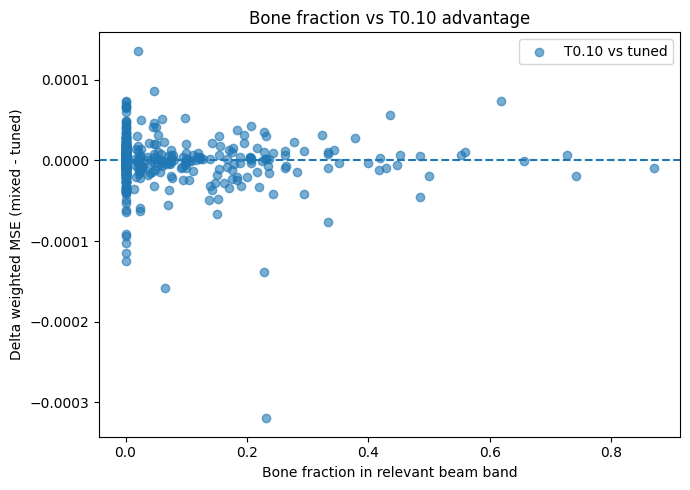

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_scatter_t010_vs_bone_fraction.png


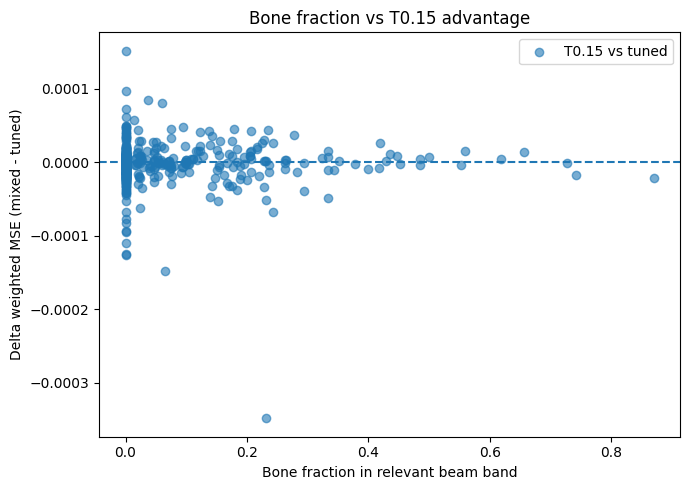

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_scatter_t015_vs_bone_fraction.png


In [16]:
plt.figure(figsize=(7,5))
plt.scatter(
    case_compare_df["bone_fraction_in_relevant_band"],
    case_compare_df["delta_weighted_t010_vs_tuned"],
    alpha=0.6,
    label="T0.10 vs tuned"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Bone fraction in relevant beam band")
plt.ylabel("Delta weighted MSE (mixed - tuned)")
plt.title("Bone fraction vs T0.10 advantage")
plt.legend()
plt.tight_layout()

scatter_t010_path = OUT_DIR / "ct2dose_case_type_analysis_scatter_t010_vs_bone_fraction.png"
plt.savefig(scatter_t010_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", scatter_t010_path)


plt.figure(figsize=(7,5))
plt.scatter(
    case_compare_df["bone_fraction_in_relevant_band"],
    case_compare_df["delta_weighted_t015_vs_tuned"],
    alpha=0.6,
    label="T0.15 vs tuned"
)
plt.axhline(0, linestyle="--")
plt.xlabel("Bone fraction in relevant beam band")
plt.ylabel("Delta weighted MSE (mixed - tuned)")
plt.title("Bone fraction vs T0.15 advantage")
plt.legend()
plt.tight_layout()

scatter_t015_path = OUT_DIR / "ct2dose_case_type_analysis_scatter_t015_vs_bone_fraction.png"
plt.savefig(scatter_t015_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", scatter_t015_path)

### Step 17 — Simple win-summary table for Trello

In [17]:
trello_case_type_table = case_winner_df[
    [
        "sample_idx",
        "bone_in_beam_candidate",
        "bone_fraction_in_relevant_band",
        "max_hu_in_relevant_band",
        "weighted_mse_winner",
        "overall_mae_winner",
        "high_mae_winner",
        "peak_core_mae_winner",
        "peak_shoulder_mae_winner",
    ]
].copy()

trello_case_type_csv = OUT_DIR / "ct2dose_case_type_analysis_trello_case_winner_table.csv"
trello_case_type_table.to_csv(trello_case_type_csv, index=False)

print("Saved:", trello_case_type_csv)
display(trello_case_type_table.head(20))

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_trello_case_winner_table.csv


,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,weighted_mse_winner,overall_mae_winner,high_mae_winner,peak_core_mae_winner,peak_shoulder_mae_winner
0,0,True,0.184211,830.923096,mixed_T010_a030_mw3,tuned,tuned,mixed_T010_a030_mw3,mixed_T010_a030_mw3
1,1,False,0.000000,48.529053,mixed_T015_a030_mw3,tuned,mixed_T015_a030_mw3,mixed_T010_a030_mw3,mixed_T015_a030_mw3
2,2,True,0.117647,903.819946,tuned,tuned,mixed_T010_a030_mw3,mixed_T015_a030_mw3,tuned
3,3,True,0.435897,746.846069,tuned,tuned,tuned,mixed_T015_a030_mw3,mixed_T015_a030_mw3
4,4,False,0.000000,90.889771,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T015_a030_mw3
5,5,True,0.727273,825.757935,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T010_a030_mw3,tuned,mixed_T015_a030_mw3
6,6,True,0.078947,383.574463,tuned,tuned,mixed_T010_a030_mw3,tuned,tuned
7,7,False,0.000000,57.711670,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T015_a030_mw3,mixed_T015_a030_mw3
8,8,False,0.000000,58.072632,tuned,tuned,tuned,mixed_T010_a030_mw3,tuned
9,9,False,0.000000,13.323242,tuned,tuned,tuned,tuned,tuned


### Step 18 — Compact summary table for meeting / Trello

In [18]:
compact_rows = []

for subset_value, subset_name in [(None, "all_cases"), (True, "bone_in_beam"), (False, "non_bone")]:
    if subset_value is None:
        sub = case_compare_df.copy()
    else:
        sub = case_compare_df[case_compare_df["bone_in_beam_candidate"] == subset_value].copy()

    compact_rows.append({
        "subset": subset_name,
        "num_cases": len(sub),
        "mean_delta_weighted_t010_vs_tuned": float(np.mean(sub["delta_weighted_t010_vs_tuned"])),
        "mean_delta_weighted_t015_vs_tuned": float(np.mean(sub["delta_weighted_t015_vs_tuned"])),
        "mean_delta_overall_t010_vs_tuned": float(np.mean(sub["delta_overall_t010_vs_tuned"])),
        "mean_delta_overall_t015_vs_tuned": float(np.mean(sub["delta_overall_t015_vs_tuned"])),
        "mean_delta_high_t010_vs_tuned": float(np.mean(sub["delta_high_t010_vs_tuned"])),
        "mean_delta_high_t015_vs_tuned": float(np.mean(sub["delta_high_t015_vs_tuned"])),
    })

compact_summary_df = pd.DataFrame(compact_rows)

compact_summary_csv = OUT_DIR / "ct2dose_case_type_analysis_compact_summary.csv"
compact_summary_df.to_csv(compact_summary_csv, index=False)

print("Saved:", compact_summary_csv)
display(compact_summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_case_type_analysis/ct2dose_case_type_analysis_compact_summary.csv


,subset,num_cases,mean_delta_weighted_t010_vs_tuned,mean_delta_weighted_t015_vs_tuned,mean_delta_overall_t010_vs_tuned,mean_delta_overall_t015_vs_tuned,mean_delta_high_t010_vs_tuned,mean_delta_high_t015_vs_tuned
0,all_cases,500,-1.531329e-06,-0.000002,0.000073,0.000074,-0.000077,0.000093
1,bone_in_beam,144,-5.366730e-06,-0.000002,0.000056,0.000137,-0.000208,0.000435
2,non_bone,356,2.006986e-08,-0.000002,0.000079,0.000049,-0.000024,-0.000046
